# AI vs Human Grading Analysis

## Group members

- Merite Mucyo
- Joselyne Byukusenge
- Joli Prince Izere
- Butera Nkurunziza
- Fabrice Niyigena

This notebook follows the report sections:

1. Introduction
2. Methodology
3. Data Processing
4. Data Analysis
5. Interpretation
6. Conclusion


In [37]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Set significance level for all hypothesis tests
significance_level = 0.05
print("significance level =", significance_level)

significance level = 0.05


In [38]:
# Load survey data from Excel
data = pd.read_excel("Student Perceptions of AI vs. Human Grading Dataset.xlsx")
data.head()

,Timestamp,Human_Fairness,AI_Fairness,AI_Bias_Concern,System_Preference,AI_Objectivity_Belief,Comfortable_AI_Grading_Aspects,Gender,Academic_Program,Year_of_Study
0,2026-04-07 09:12:09.582,2,2.0,3.0,Hybrid/AI Grading with Human Review (AI scores...,"Yes, AI is generally more objective",Multiple-choice quizzes,Male,Business Analytics,Year 2
1,2026-04-07 09:17:36.459,9,NaN,3.0,100% AI Grading (Fully Automated),"Yes, AI is generally more objective","Multiple-choice quizzes, Short answer question...",Male,Business Analytics,Year 3
2,2026-04-07 09:24:01.832,8,7.0,7.0,Hybrid/AI Grading with Human Review (AI scores...,Unsure,"Multiple-choice quizzes, Coding assignments",Female,Business Analytics,Year 2
3,2026-04-07 09:28:54.591,8,7.0,6.0,Hybrid/AI Grading with Human Review (AI scores...,Unsure,"Multiple-choice quizzes, Short answer question...",Male,Business Analytics,Year 2
4,2026-04-07 09:39:33.981,7,7.0,7.0,Hybrid/AI Grading with Human Review (AI scores...,"No, human grading is better or AI has new form...","Multiple-choice quizzes, Short answer question...",Male,Business Analytics,Year 2


In [39]:
# Quick structure check
print("shape:", data.shape)
print(data.columns)

shape: (116, 10)
Index(['Timestamp', 'Human_Fairness', 'AI_Fairness', 'AI_Bias_Concern',
       'System_Preference', 'AI_Objectivity_Belief',
       'Comfortable_AI_Grading_Aspects', 'Gender', 'Academic_Program',
       'Year_of_Study'],
      dtype='object')


In [40]:
# Remove timestamp column
data = data.drop(columns=["Timestamp"])

# Convert key numeric columns
cols = ["Human_Fairness", "AI_Fairness", "AI_Bias_Concern"]
data[cols] = data[cols].apply(pd.to_numeric)

# Remove duplicate responses
data = data.drop_duplicates()

# Standardize Academic_Program text
data["Academic_Program"] = data["Academic_Program"].str.strip().str.title()

print("clean shape:", data.shape)
print(data.isna().sum())
print(data["Academic_Program"].value_counts(dropna=False))

clean shape: (115, 9)
Human_Fairness                     0
AI_Fairness                        1
AI_Bias_Concern                    1
System_Preference                  0
AI_Objectivity_Belief              2
Comfortable_AI_Grading_Aspects     0
Gender                             0
Academic_Program                  18
Year_of_Study                      0
dtype: int64
Academic_Program
Business Analytics    56
Project Management    41
NaN                   18
Name: count, dtype: int64


In [41]:
# Filling missing values in Academic_Program with mode
data["Academic_Program"] = data["Academic_Program"].fillna(data["Academic_Program"].mode()[0])
print(data["Academic_Program"].value_counts(dropna=False))


Academic_Program
Business Analytics    74
Project Management    41
Name: count, dtype: int64


In [42]:
# Descriptive summary for main numeric variables
summary_cols = ["Human_Fairness", "AI_Fairness", "AI_Bias_Concern"]
print(data[summary_cols].describe().T[["count", "mean", "std", "min", "max"]])

                 count      mean       std  min   max
Human_Fairness   115.0  6.895652  2.514428  1.0  10.0
AI_Fairness      114.0  6.061404  2.324495  1.0  10.0
AI_Bias_Concern  114.0  6.201754  2.270160  1.0  10.0


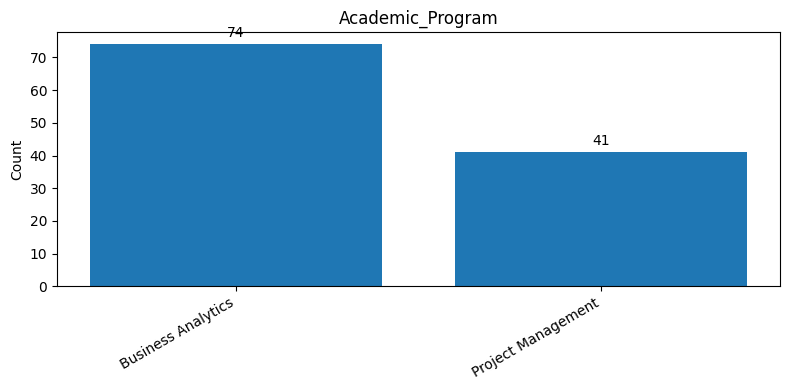

In [60]:
plt.figure(figsize=(8,4))
program_counts = data["Academic_Program"].value_counts()
bars = plt.bar(program_counts.index, program_counts.values)
plt.title("Academic_Program")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
# Add numeric labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height)}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [61]:
# Build paired dataset for within-student fairness comparison
paired = data[["Human_Fairness", "AI_Fairness"]].dropna()
paired = paired.assign(diff=paired["Human_Fairness"] - paired["AI_Fairness"])
print("paired n =", len(paired))

paired n = 114


In [54]:
# Paired t-test: same students rate Human and AI fairness
t_stat, p_value = stats.ttest_rel(paired["Human_Fairness"], paired["AI_Fairness"])

# Confidence interval for mean difference (Human - AI)
m = paired["diff"].mean()
s = paired["diff"].std(ddof=1)
se = s / np.sqrt(len(paired))
t_crit = stats.t.ppf(1 - significance_level / 2, len(paired) - 1)
ci_low = m - t_crit * se
ci_high = m + t_crit * se
decision = np.array(["Fail to reject H0", "Reject H0"])[int(p_value < significance_level)]

print("t =", round(t_stat, 4), "p =", round(p_value, 6))
print("95% CI:", round(ci_low, 3), round(ci_high, 3))
print("Decision:", decision)

t = 2.6518 p = 0.009156
95% CI: 0.206 1.425
Decision: Reject H0


## Additional Analysis (By Academic Program)

**Test 2: Chi-square test of independence**

Research question: Is preferred grading system associated with academic program?

- H0: Academic_Program and Preferred Grading System are independent.
- H1: Academic_Program and Preferred Grading System are associated.


In [55]:
# Test 2: Chi-square test (Academic_Program vs Preferred Grading System)
prog_data = data[data["Academic_Program"].isin(["Business Analytics", "Project Management"])].copy()

# Group long preference text into Human / AI / Hybrid
pref_text = prog_data["System_Preference"].fillna("").astype(str).str.strip().str.lower()
prog_data["Preference_Group"] = np.select(
    [pref_text.str.contains("hybrid"), pref_text.str.contains("human"), pref_text.str.contains("100% ai|ai grading")],
    ["Hybrid", "Human", "AI"],
    default="Other"
)

# Build contingency table and run chi-square test
ct = pd.crosstab(prog_data["Academic_Program"], prog_data["Preference_Group"])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
chi_decision = "Reject H0" if p_chi < significance_level else "Fail to reject H0"

print("Chi-square test: Academic_Program vs Preferred Grading System")
print(ct)
print(f"chi2={chi2:.4f}, p={p_chi:.6f}, dof={dof}, decision={chi_decision}")

Chi-square test: Academic_Program vs Preferred Grading System
Preference_Group    AI  Human  Hybrid
Academic_Program                     
Business Analytics  11     31      32
Project Management   7     15      19
chi2=0.3250, p=0.850003, dof=2, decision=Fail to reject H0


Comfortable_AI_Grading_Aspects
Multiple-choice quizzes                    88
Short answer questions (factual recall)    52
Coding assignments                         45
Essays/Long-form written papers            36
Presentations/Oral assessments             18
Name: count, dtype: int64


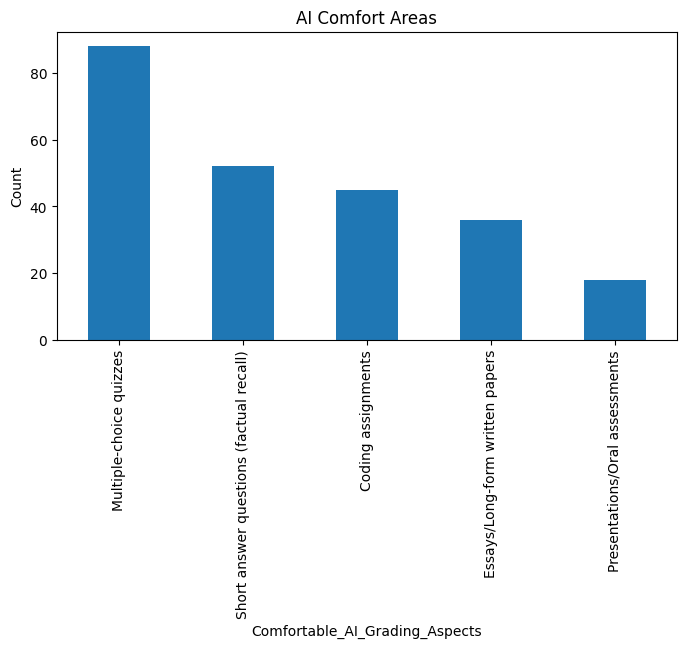

In [56]:
# Count selected comfort areas for AI grading
areas = data["Comfortable_AI_Grading_Aspects"].dropna().astype(str).str.split(",").explode().str.strip()
areas = areas[areas != ""]
count = areas.value_counts()
print(count)

count.plot(kind="bar", figsize=(8,4), title="AI Comfort Areas")
plt.ylabel("Count")
plt.show()

In [57]:
# Final summary values for report write-up
print("Mean Human Fairness =", round(paired["Human_Fairness"].mean(), 2))
print("Mean AI Fairness =", round(paired["AI_Fairness"].mean(), 2))
print("Paired t-test p-value =", round(p_value, 6))
print("Decision:", decision)
print("Significance level =", significance_level)

Mean Human Fairness = 6.88
Mean AI Fairness = 6.06
Paired t-test p-value = 0.009156
Decision: Reject H0
Significance level = 0.05


## Conclusion

Students rated human grading higher than AI grading in this sample. The paired t-test gives the main result for the hypothesis.

The hypothesis statements were:

Paired t-test: there is no difference between the mean fairness rating of human grading and AI grading.
Chi-square test: academic program and preferred grading system are independent.
The decisions are:

Paired t-test: Reject H0, with p = 0.009156.
Chi-square test: Fail to reject H0, with p = 0.850003.
